Running h = 0.1
Approximate number of steps: 300


<ipython-input-3-16dabc0e687f>:5: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-3-16dabc0e687f>:16: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])


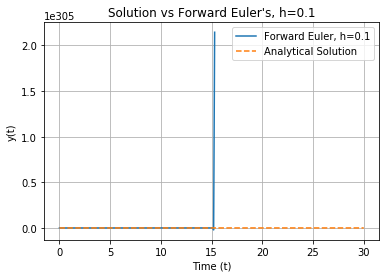

Running h = 0.01
Approximate number of steps: 3000


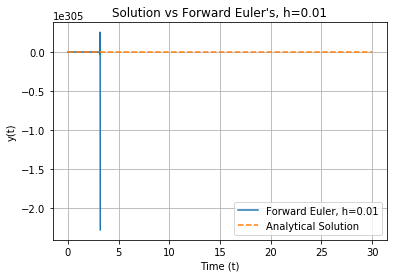

Running h = 0.001
Approximate number of steps: 30000


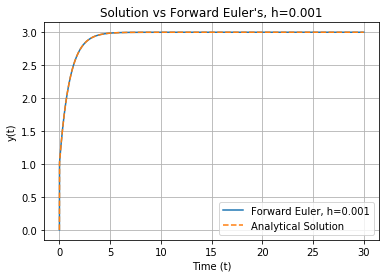

Running h = 1e-05
Approximate number of steps: 2999999


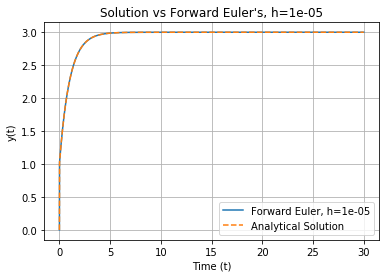

Running h = 1e-07
Approximate number of steps: 300000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0

    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])

    return t_values, y_values

y0 = 0
t0 = 0
tf = 30
h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

t_exact = np.linspace(t0, tf, 2000)
y_true = y_exact(t_exact)

for h in h_values:
    print(f"Running h = {h}")

    n_steps = int((tf - t0) / h)
    print(f"Approximate number of steps: {n_steps}")

    t_values, y_values = forward_euler(f, y0, t0, tf, h)

    plt.plot(t_values, y_values, label=f"Forward Euler, h={h}")
    plt.plot(t_exact, y_true, '--', label="Analytical Solution")
    plt.xlabel('Time (t)')
    plt.ylabel('y(t)')
    plt.title(f"Solution vs Forward Euler's, h={h}")
    plt.legend()
    plt.grid(True)
    plt.show()